# Machine Learning Pipeline to Predict Gene Set Association in Diseases

This pipeline is designed to load, inspect, process and use the data provided to train a Machine Learning Model. The model is trained on a binary classification probelm, where it is tasked with predicting whether a given set of genes contributes to the same disease or not.

Initially, we load the required Python libraries.

In [1]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate, GridSearchCV

In [2]:
# @title Download test data
file_id = '1qXFJPcwPGASX581Do6cYsP1A4n5_HdmS'
gdown.download(id=file_id,  quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1qXFJPcwPGASX581Do6cYsP1A4n5_HdmS
To: /content/test.csv
100%|██████████| 12.5M/12.5M [00:00<00:00, 92.8MB/s]


'test.csv'

In [3]:
# @title Download training data
file_id ='13CxaCVT-V0M6DZuq38p38U_FE50rxXnN'
gdown.download(id=file_id,  quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=13CxaCVT-V0M6DZuq38p38U_FE50rxXnN
From (redirected): https://drive.google.com/uc?id=13CxaCVT-V0M6DZuq38p38U_FE50rxXnN&confirm=t&uuid=6ba7b2e7-d8d2-4081-b301-463aa929b6bd
To: /content/train.csv
100%|██████████| 168M/168M [00:01<00:00, 112MB/s]


'train.csv'

In [4]:
# @title Load training and hidden test data to dataframe's and make sure to keep ID column
train_df=pd.read_csv("train.csv")
test_df=pd.read_csv("test.csv")
train_df.set_index("ID", inplace=True)
test_df.set_index("ID", inplace=True)

### Inspect the first 5 rows of the training and test datasets.

In [5]:
train_df.head()

,disease,rep,num_genes,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511,sc,y
ID,,,,,,,,,,,,,,,,,,,,,
0,0,3,0.005,0.004273,0.023922,0.004779,-0.006661,-0.021735,-0.015244,-0.014190,...,-0.006410,-0.001173,0.000742,0.032013,-0.023418,-0.005270,-0.013441,0.023032,-0.279251,0
1,1,5,0.006,-0.025024,-0.022999,0.002726,-0.003353,0.009228,0.005893,-0.027819,...,-0.002209,-0.008278,-0.023273,0.036092,-0.000172,-0.002832,0.003810,0.003941,0.702937,0
2,1,1,0.006,-0.028817,0.028247,0.013252,-0.010952,-0.014338,0.009508,-0.032441,...,0.003875,0.005103,0.033030,0.022815,-0.013812,0.011468,-0.014250,-0.001468,0.830819,1
3,1,1,0.006,-0.000204,-0.012802,0.012755,0.007765,-0.019451,-0.019098,-0.022202,...,0.007107,-0.011549,-0.011626,0.031835,-0.034214,-0.004068,-0.002463,0.010000,1.694757,1
4,1,2,0.004,0.017057,0.017862,0.036861,-0.004437,-0.041073,-0.007223,0.008667,...,0.033768,0.004372,0.019167,-0.003028,-0.011156,0.000360,-0.009348,0.003702,0.470963,0


In [6]:
test_df.head()

,disease,rep,num_genes,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511,sc
ID,,,,,,,,,,,,,,,,,,,,,
15411,1,1,0.008,0.001202,-0.027142,-0.003757,0.019419,-0.002351,0.001093,0.017700,...,0.006791,0.002623,0.011053,-0.012288,0.031494,0.008430,0.002696,-0.001119,-0.006862,0.0
15412,1,1,0.004,-0.018384,-0.019520,0.009691,0.005816,-0.013052,0.004658,-0.012587,...,-0.000503,0.050537,-0.005517,0.043266,-0.053341,-0.022226,0.003294,0.007130,0.012606,0.0
15413,1,1,0.013,-0.007002,-0.005490,0.008867,-0.000167,0.003577,-0.005832,-0.027851,...,-0.005709,0.005699,-0.011145,0.005563,-0.008014,-0.023620,0.003503,-0.007236,-0.001138,0.0
15414,0,1,0.011,-0.016772,-0.028181,0.010672,-0.013148,-0.000051,-0.002579,-0.011291,...,-0.003747,0.009239,0.001087,0.000988,-0.011656,-0.031811,0.001185,-0.004933,-0.003273,0.0
15415,1,1,0.004,-0.037281,-0.127243,-0.007415,-0.020436,0.014132,0.017750,0.057547,...,-0.011965,0.004094,0.000575,0.025002,-0.034524,0.006857,-0.007941,0.012630,-0.047178,0.0


### View the shape of the datasets and distribution/balance of the two classes (0 and 1)

In [7]:
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist()[:10], "...")

print("\nDtypes:")
print(train_df.dtypes.value_counts())

print("\nTarget balance:")
print(train_df['y'].value_counts())
print(train_df['y'].value_counts(normalize=True))

train shape: (15411, 517)
test shape: (1154, 516)

Train columns:
['disease', 'rep', 'num_genes', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6'] ...

Dtypes:
float64    514
int64        3
Name: count, dtype: int64

Target balance:
y
0    12810
1     2601
Name: count, dtype: int64
y
0    0.831224
1    0.168776
Name: proportion, dtype: float64


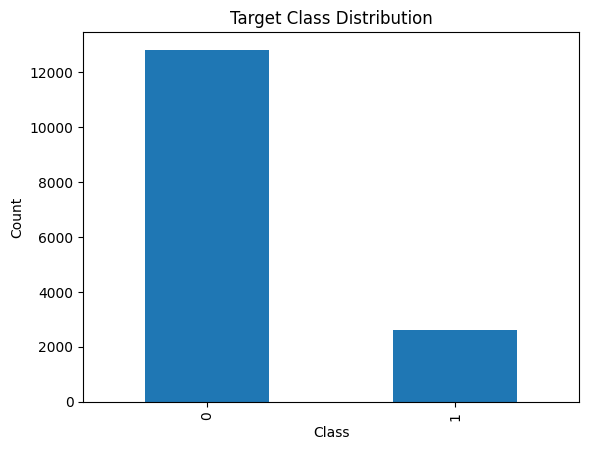

In [8]:
train_df['y'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Target Class Distribution")
plt.show()

We see that the two classes are imbalanced with the negative (zero) appearing far more frequently, which should be taken into account in pipeline construction.

### Inspecting the data for any missing values

In [9]:
missing_train = train_df.isna().sum()
missing_test = test_df.isna().sum()

print("Missing values in train:")
print(missing_train[missing_train > 0].sort_values(ascending=False).head(20))

print("\nMissing values in test:")
print(missing_test[missing_test > 0].sort_values(ascending=False).head(20))

Missing values in train:
Series([], dtype: int64)

Missing values in test:
Series([], dtype: int64)


In [10]:
print("Any inf in train:", np.isinf(train_df.select_dtypes(include=[float, int])).sum().sum())
print("Any inf in test:", np.isinf(test_df.select_dtypes(include=[float, int])).sum().sum())

Any inf in train: 0
Any inf in test: 0


No missing values were observed in either training or test datasets. However, a median imputation step was retained in the pipeline to ensure robustness and prevent potential failures during deployment.

### Information about the dataset

X_train input features:

Disease: Binary input indicating if, 1 = Disease predominantly driven by germline mutations or 0 = Disease predominantly driven by somatic mutations

rep: Integer (1–5) indicating the repeat index from a data augmentation strategy (to increase training dataset size).

emb_0 to emb_511: 512-dimensional feature vector, Deep learning–derived embedding of publicly available multi-omics data for each gene set

sc: Literature-based co-mention score derived from in-house computational analysis of PubMed (January 2025).
Providing a normalised measure of how frequently genes in a set are mentioned together in the context of the same disease.
Higher values indicate a greater likelihood that the genes are associated with the same disease

num_genes: Number of genes in the gene set being evaluated, divided by 1000

y_train target features you are aiming to predict with your ML method:

y: Binary target feature, 1==Genes are involved in the same disease, 0==Genes are not involved in the same disease

### Further inspections of the features.

In [11]:
print(train_df['rep'].value_counts().sort_index())
print(test_df['rep'].value_counts().sort_index())

rep
1    5155
2    2568
3    2574
4    2564
5    2550
Name: count, dtype: int64
rep
1    1154
Name: count, dtype: int64


In [12]:
train_df[['disease', 'rep', 'num_genes', 'sc']].describe()

,disease,rep,num_genes,sc
count,15411.000000,15411.000000,15411.000000,15411.000000
mean,0.717669,2.661670,0.012633,0.168001
std,0.450148,1.489482,0.034077,0.591673
min,0.000000,1.000000,0.004000,-0.799985
25%,0.000000,1.000000,0.004000,-0.320407
50%,1.000000,2.000000,0.005000,0.159906
75%,1.000000,4.000000,0.008000,0.565980
max,1.000000,5.000000,0.643000,1.798815


In [13]:
test_df[['disease', 'rep', 'num_genes', 'sc']].describe()

,disease,rep,num_genes,sc
count,1154.000000,1154.0,1154.000000,1154.0
mean,0.736568,1.0,0.011804,0.0
std,0.440685,0.0,0.031262,0.0
min,0.000000,1.0,0.004000,0.0
25%,0.000000,1.0,0.004000,0.0
50%,1.000000,1.0,0.005000,0.0
75%,1.000000,1.0,0.008000,0.0
max,1.000000,1.0,0.385000,0.0


In [14]:
emb_cols = [c for c in train_df.columns if c.startswith("emb_")]
meta_cols = ['disease', 'num_genes', 'sc']
print("Number of embedding columns:", len(emb_cols))
print("Metadata columns:", meta_cols)

Number of embedding columns: 512
Metadata columns: ['disease', 'num_genes', 'sc']


In [15]:
train_df[emb_cols].describe().T[['mean', 'std', 'min', 'max']].head(10)

,mean,std,min,max
emb_0,-0.002903,0.016628,-0.105392,0.088596
emb_1,-0.005523,0.024033,-0.170685,0.151733
emb_2,0.005072,0.012832,-0.085974,0.068207
emb_3,-0.001200,0.010317,-0.071956,0.073624
emb_4,-0.003842,0.015424,-0.066614,0.080795
emb_5,-0.001734,0.007724,-0.049652,0.055981
emb_6,-0.007852,0.018341,-0.102608,0.094162
emb_7,0.001739,0.031190,-0.140228,0.169678
emb_8,-0.000916,0.008296,-0.046959,0.052231
emb_9,0.008095,0.017363,-0.090851,0.121185


In [16]:
test_df[emb_cols].describe().T[['mean', 'std', 'min', 'max']].head(10)

,mean,std,min,max
emb_0,-0.002653,0.018897,-0.073938,0.079201
emb_1,-0.004980,0.027000,-0.150162,0.126317
emb_2,0.004739,0.015633,-0.077795,0.057465
emb_3,-0.000830,0.012269,-0.051834,0.053024
emb_4,-0.004093,0.018480,-0.065842,0.075729
emb_5,-0.002055,0.008954,-0.034538,0.049675
emb_6,-0.007335,0.022688,-0.076008,0.085419
emb_7,0.002771,0.036570,-0.123428,0.164536
emb_8,-0.000903,0.009634,-0.046276,0.040135
emb_9,0.008429,0.021172,-0.093994,0.108246


The data contains high-dimensional numerical embeddings, representing complex (and typically) non-linear relationships that are better captured by tree-based models.

The dataset contains numerical features, ideal for incorporation into a scikit-learn pipeline. The rep feature was dropped from training as it represents data augmentation rather than biological signal. Also, the test dataset contains only rep=1, which would negatively affect generalization if included.
Additionally, the co-mention score (sc) feature has no variability in the test set (as all values are zero). It is thus dropped from training so as to not hurt generalization.

In [17]:
# Preparing training and test data
X = train_df.drop(columns=["rep", "y", "sc"])
y =  train_df["y"]
X_test = test_df.drop(columns=["rep", "sc"])

Benchmarking Logistic Regression, Random Forest, and HistGradientBoostingClassifier models using stratified 3-fold cross-validation.

In [18]:
cv = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
models = {
    "HistGB": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingClassifier(
            max_depth=8,
            learning_rate=0.03,
            max_iter=300,
            random_state=42,
        ))
    ]),

    "RandomForest": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "LogisticRegression": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])
}

scoring = ['f1_macro', 'balanced_accuracy']

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "model": name,
        "f1_macro": scores['test_f1_macro'].mean(),
        "balanced_acc": scores['test_balanced_accuracy'].mean()
    })

results_df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False)

print(results_df)

                model  f1_macro  balanced_acc
0              HistGB  0.897976      0.854308
1        RandomForest  0.762454      0.705720
2  LogisticRegression  0.505710      0.557936


The gradient boosting model achieved the highest macro F1-score, outperforming the others. This indicates the presence of nonlinear relationships in the data, which are better captured by boosting methods. F1_macro score is used as the primary performance metric as it balances precision and recall for both classes, ensuring both classes are given equal importance.

To further improve performance of HistGradientBoostingClassifier, we finetune its hyperparameters using GridSearchCV (5-fold).

In [19]:
# Defining hyperparameter grid
param_grid = {
    "model__max_depth": [16, 17, 18],
    "model__learning_rate": [0.02, 0.025],
    "model__max_iter": [750, 850]
}

In [20]:
# Running a gridsearch on the model selected for hyperparameter finetuning
clf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ("model", HistGradientBoostingClassifier(random_state=42))
])
# Setting up GridSearchCV with 5-fold cross-validation and f1_macro as the performance measure
grid_search = GridSearchCV(
    clf,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=3
)

In [21]:
# Fitting the GridSearchCV
grid_search.fit(X, y)
# See best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'model__learning_rate': 0.02, 'model__max_depth': 17, 'model__max_iter': 750}
Best score: 0.9249869330672243


After running the grid search, we obtain the best parameters for the model and use the **best_estimator_** from it. We then fit the best model on the entire training data prior to making final predictions.

In [22]:
# Fit best model on full training set
best_model = grid_search.best_estimator_
best_model.fit(X, y)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 HistGradientBoostingClassifier(learning_rate=0.02,
                                                max_depth=17, max_iter=750,
                                                random_state=42))])

### Making predictions using the finalized best model.

In [23]:
# Make predictions on hidden test set
test_preds = best_model.predict(X_test)

In [24]:
# @title Write outputs for uploading to turnitin

In [25]:
#test_df = test_df.reset_index()
#df_res_test=test_df[["ID"]].copy()
df_res_test = pd.DataFrame({
    "ID": test_df.index,
    "PREDICTION": test_preds.astype(int)
})
#df_res_test["PREDICTION"] = list(test_preds)
df_res_test.to_csv("ml_results.csv", index=False)

In [26]:
# @title Check there are 2 columns and that the ID starts at 15411
!head -n3  ml_results.csv

ID,PREDICTION
15411,0
15412,0


In [27]:
# @title Check there are 1155 predictions (full test set)
!wc -l ml_results.csv

1155 ml_results.csv
